# Ratings vs Trailing Returns

Do our report scores and verdicts predict stock performance? This notebook loads every `FINAL-REPORT.json`, fetches trailing returns from Yahoo Finance, and checks.

In [1]:
from __future__ import annotations
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import yfinance as yf

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', font_scale=1.1, palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 120, 'figure.facecolor': 'white'})

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'run.sh').exists())
if not (REPO_ROOT / 'runs').exists():
    REPO_ROOT = Path.cwd()
REPORT_GLOB = 'runs/*/reports/*/FINAL-REPORT.json'
RETURN_WINDOWS = {'1m': 1, '3m': 3, '6m': 6, '1y': 12, '3y': 36}
VERDICT_ORDER = ['Own', 'Watch', 'Pass']
VERDICT_COLORS = {'Own': '#2ecc71', 'Watch': '#f39c12', 'Pass': '#e74c3c'}
UMBRELLA_ORDER = [
    'circle_of_competence', 'competitive_advantage', 'management',
    'business_economics', 'balance_sheet', 'valuation',
    'margin_of_safety', 'temperament',
]
UMBRELLA_SHORT = ['Competence', 'Moat', 'Mgmt', 'Economics', 'Balance', 'Valuation', 'MOS', 'Temperament']
return_cols = [f'return_{k}_pct' for k in RETURN_WINDOWS]
print(f'{REPO_ROOT}  |  glob: {REPORT_GLOB}')

/Users/jep/Desktop/portfolio-and-investment  |  glob: runs/*/reports/*/FINAL-REPORT.json


In [2]:
def flatten_report(report, path):
    scores = report.get('umbrella_scores') or {}
    row = dict(
        ticker=report.get('ticker') or path.parent.name,
        company=report.get('company') or path.parent.name,
        analysis_date=report.get('analysis_date'),
        verdict=report.get('verdict'),
        average_score=report.get('average_score'),
        confidence=report.get('confidence'),
        red_flag_count=len(report.get('red_flags') or []),
    )
    for k in UMBRELLA_ORDER:
        row[k] = scores.get(k)
    return row

rows = []
for p in sorted(REPO_ROOT.glob(REPORT_GLOB)):
    try:
        rows.append(flatten_report(json.loads(p.read_text()), p))
    except (OSError, json.JSONDecodeError):
        pass

raw = pd.DataFrame(rows)
raw['analysis_date'] = pd.to_datetime(raw['analysis_date'], errors='coerce')

# keep latest report per ticker, then dedupe by company name
df = (raw.sort_values(['ticker', 'analysis_date'])
      .drop_duplicates('ticker', keep='last')
      .reset_index(drop=True))
norm = df['company'].str.strip().str.lower().str.rstrip('.').str.replace(',', '', regex=False)
df = df.assign(company_norm=norm)
df = (df.sort_values(['company_norm', 'analysis_date'])
      .drop_duplicates('company_norm', keep='last')
      .reset_index(drop=True))

df['verdict'] = pd.Categorical(df['verdict'], categories=VERDICT_ORDER, ordered=True)

print(f'Universe: {len(df)} companies  |  {len(rows)} raw reports')
print(f'Verdicts: {df["verdict"].value_counts().to_dict()}')
print(f'Score range: {df["average_score"].min():.1f} - {df["average_score"].max():.1f}')
print(f'Dates: {df["analysis_date"].min().date()} to {df["analysis_date"].max().date()}')

Universe: 87 companies  |  100 raw reports
Verdicts: {'Watch': 56, 'Pass': 18, 'Own': 13}
Score range: 3.2 - 8.4
Dates: 2026-03-06 to 2026-03-24


In [3]:
def get_returns(ticker, end_date, windows):
    hist = yf.download(ticker, period='5y', interval='1d', auto_adjust=True, progress=False, threads=False)
    if hist.empty:
        return None
    if isinstance(hist.columns, pd.MultiIndex):
        hist.columns = hist.columns.get_level_values(0)
    prices = hist[['Close']].rename(columns={'Close': 'close'}).dropna()
    prices.index = pd.to_datetime(prices.index).tz_localize(None)
    prices = prices.sort_index()
    
    sub = prices.loc[prices.index <= end_date]
    if sub.empty:
        return None
    end_close = float(sub.iloc[-1]['close'])
    end_dt = sub.index[-1]
    
    result = {'ticker': ticker, 'price': end_close}
    for label, months in windows.items():
        target = end_dt - pd.DateOffset(months=months)
        before = prices.loc[prices.index <= target]
        if before.empty:
            result[f'return_{label}_pct'] = np.nan
        else:
            result[f'return_{label}_pct'] = (end_close / float(before.iloc[-1]['close']) - 1) * 100
    return result

end_date = pd.Timestamp.today().normalize()
ret_rows, errs = [], []
for i, t in enumerate(df['ticker'], 1):
    if i % 20 == 0 or i == len(df):
        print(f'  {i}/{len(df)}', end='\r')
    try:
        r = get_returns(t, end_date, RETURN_WINDOWS)
        if r:
            ret_rows.append(r)
        else:
            errs.append(t)
    except Exception:
        errs.append(t)

ret_df = pd.DataFrame(ret_rows)
df = df.merge(ret_df, on='ticker', how='left')
n_ok = ret_df[return_cols[0]].notna().sum()
print(f'Fetched prices for {len(ret_rows)}/{len(df)} tickers  |  {len(errs)} errors: {errs if errs else "none"}')

Fetched prices for 87/87 tickers  |  0 errors: none


## Top & Bottom by Average Score

In [4]:
show_cols = ['ticker', 'verdict', 'average_score', 'return_1m_pct', 'return_3m_pct', 'return_6m_pct', 'return_1y_pct']
sorted_df = df.sort_values('average_score', ascending=False)

def fmt_table(sub):
    s = sub[show_cols].copy()
    for c in show_cols[3:]:
        s[c] = s[c].map(lambda x: f'{x:+.1f}%' if pd.notna(x) else '')
    s['average_score'] = s['average_score'].map('{:.1f}'.format)
    s.columns = ['Ticker', 'Verdict', 'Score', '1m', '3m', '6m', '1y']
    return s.reset_index(drop=True)

print('--- Top 15 ---')
display(fmt_table(sorted_df.head(15)))
print('\n--- Bottom 10 ---')
display(fmt_table(sorted_df.tail(10)))

--- Top 15 ---


,Ticker,Verdict,Score,1m,3m,6m,1y
0,WKL.AS,Own,8.4,+0.9%,-28.9%,-44.4%,-55.3%
1,CSU.TO,Own,8.4,+2.9%,-26.5%,-41.1%,-48.4%
2,BRK-B,Own,8.2,-2.5%,-3.8%,-3.0%,-8.3%
3,V,Own,8.1,-1.0%,-14.2%,-9.8%,-10.9%
4,CB,Own,8.1,-2.3%,+5.1%,+18.3%,+13.3%
5,MRSH,Own,8.1,-2.8%,-7.1%,-12.3%,-24.8%
6,MA,Own,8.1,+0.4%,-13.6%,-11.8%,-7.5%
7,RMS.PA,Watch,8.0,-20.4%,-20.7%,-19.6%,-32.9%
8,CPRT,Own,8.0,-6.1%,-15.3%,-27.0%,-39.9%
9,VEEV,Watch,7.8,+1.7%,-19.9%,-35.7%,-25.2%



--- Bottom 10 ---


,Ticker,Verdict,Score,1m,3m,6m,1y
0,ARM,Pass,5.2,+7.4%,+23.4%,-4.6%,+10.2%
1,MMM,Watch,5.2,-11.3%,-7.5%,-3.6%,-1.8%
2,MAERSK-B.CO,Pass,4.9,+7.9%,+15.6%,+27.9%,+40.5%
3,CVS,Pass,4.8,-3.3%,-8.6%,-4.5%,+10.2%
4,ORSTED.CO,Pass,4.4,-10.6%,+18.3%,+18.9%,-55.7%
5,AFRM,Pass,4.4,-6.0%,-40.8%,-44.8%,-14.3%
6,TSLA,Pass,4.1,-5.9%,-20.7%,-13.0%,+38.3%
7,HIMS,Pass,4.0,+41.4%,-36.9%,-58.9%,-41.6%
8,RKLB,Pass,3.9,-5.5%,-14.3%,+35.8%,+227.2%
9,ALMU,Pass,3.2,-25.4%,-17.7%,-30.8%,+117.2%


## Returns by Verdict Group

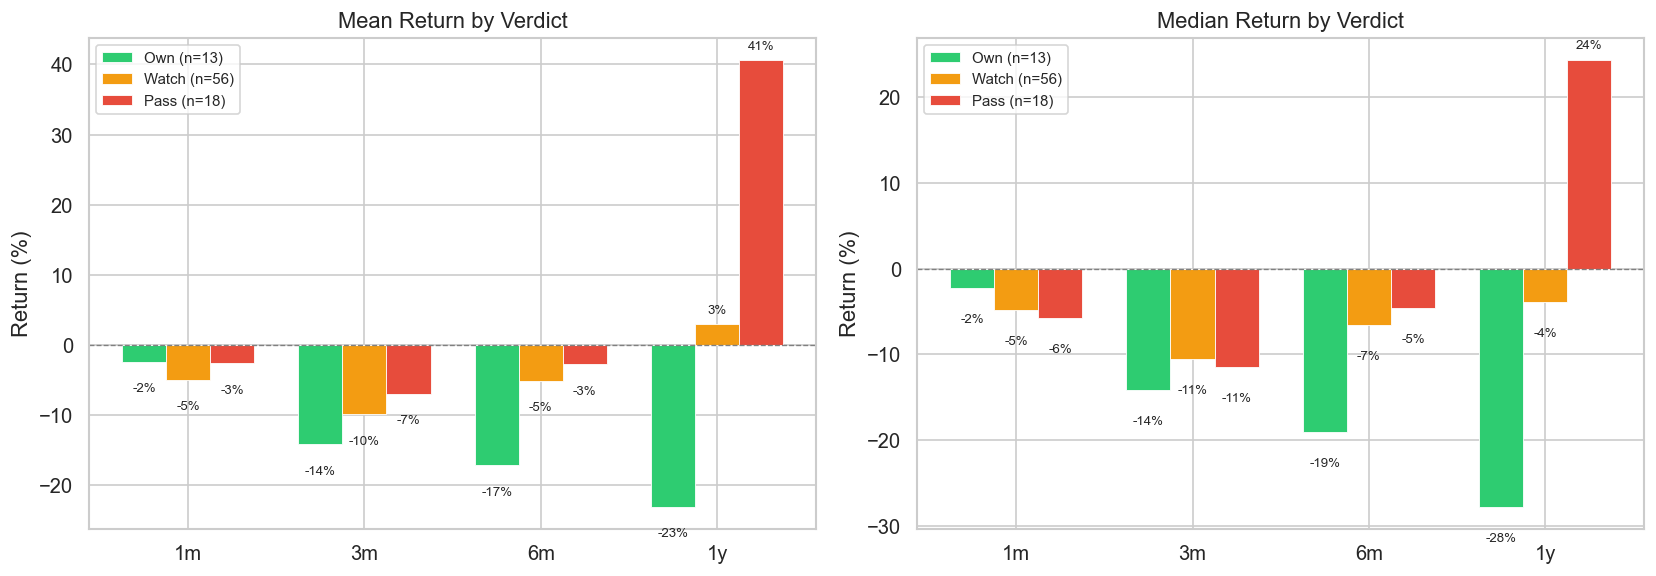

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stat_name in zip(axes, ['mean', 'median']):
    data = []
    for v in VERDICT_ORDER:
        sub = df.loc[df['verdict'] == v]
        for label in ['1m', '3m', '6m', '1y']:
            col = f'return_{label}_pct'
            vals = sub[col].dropna()
            stat = vals.mean() if stat_name == 'mean' else vals.median()
            data.append({'Verdict': v, 'Horizon': label, 'Return': stat, 'n': len(vals)})
    plot_df = pd.DataFrame(data)
    
    x = np.arange(4)
    width = 0.25
    for i, v in enumerate(VERDICT_ORDER):
        sub = plot_df[plot_df['Verdict'] == v]
        bars = ax.bar(x + i * width, sub['Return'], width, label=f"{v} (n={sub['n'].iloc[0]})",
                      color=VERDICT_COLORS[v], edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, sub['Return']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (1 if val >= 0 else -3),
                    f'{val:.0f}%', ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(['1m', '3m', '6m', '1y'])
    ax.set_ylabel('Return (%)')
    ax.set_title(f'{stat_name.title()} Return by Verdict')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Score-Return Correlations

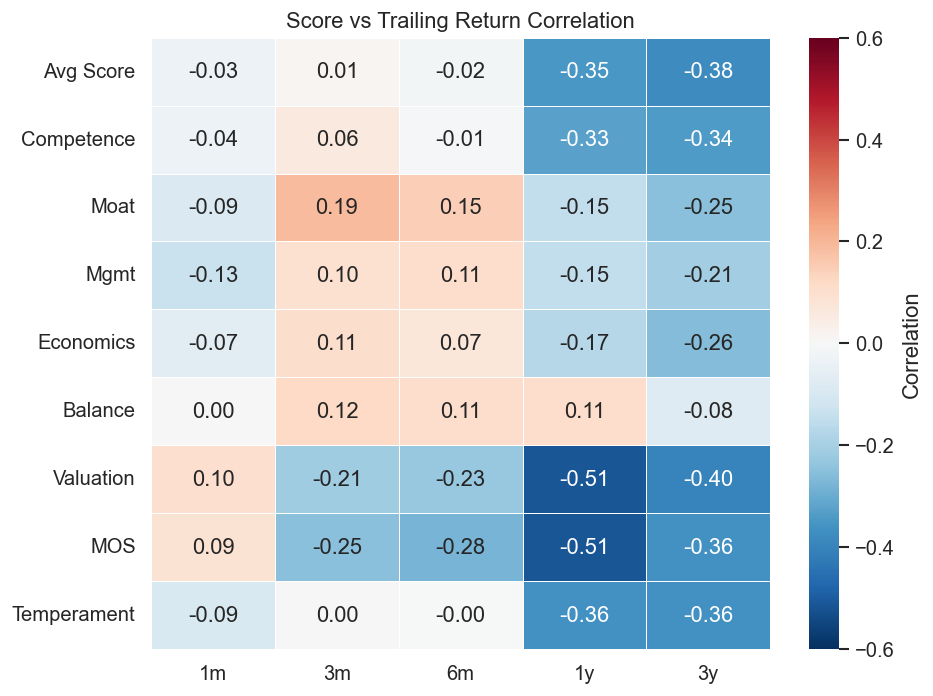

  Notable: Avg Score vs 1y = -0.35
  Notable: Avg Score vs 3y = -0.38
  Notable: Competence vs 1y = -0.33
  Notable: Competence vs 3y = -0.34
  Notable: Economics vs 3y = -0.26
  Notable: Valuation vs 1y = -0.51
  Notable: Valuation vs 3y = -0.40
  Notable: MOS vs 3m = -0.25
  Notable: MOS vs 6m = -0.28
  Notable: MOS vs 1y = -0.51
  Notable: MOS vs 3y = -0.36
  Notable: Temperament vs 1y = -0.36
  Notable: Temperament vs 3y = -0.36


In [6]:
score_cols = ['average_score'] + UMBRELLA_ORDER
score_labels = ['Avg Score'] + UMBRELLA_SHORT
ret_labels = list(RETURN_WINDOWS.keys())

corr = df[score_cols + return_cols].corr(numeric_only=True).loc[score_cols, return_cols]
corr.index = score_labels
corr.columns = ret_labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', center=0, cmap='RdBu_r', vmin=-0.6, vmax=0.6,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Score vs Trailing Return Correlation')
plt.tight_layout()
plt.show()

# highlight notable correlations
for si, sl in zip(score_cols, score_labels):
    for ri, rl in zip(return_cols, ret_labels):
        c = df[[si, ri]].dropna().corr().iloc[0, 1]
        if abs(c) >= 0.25:
            print(f'  Notable: {sl} vs {rl} = {c:+.2f}')

## Score vs Returns (Scatter)

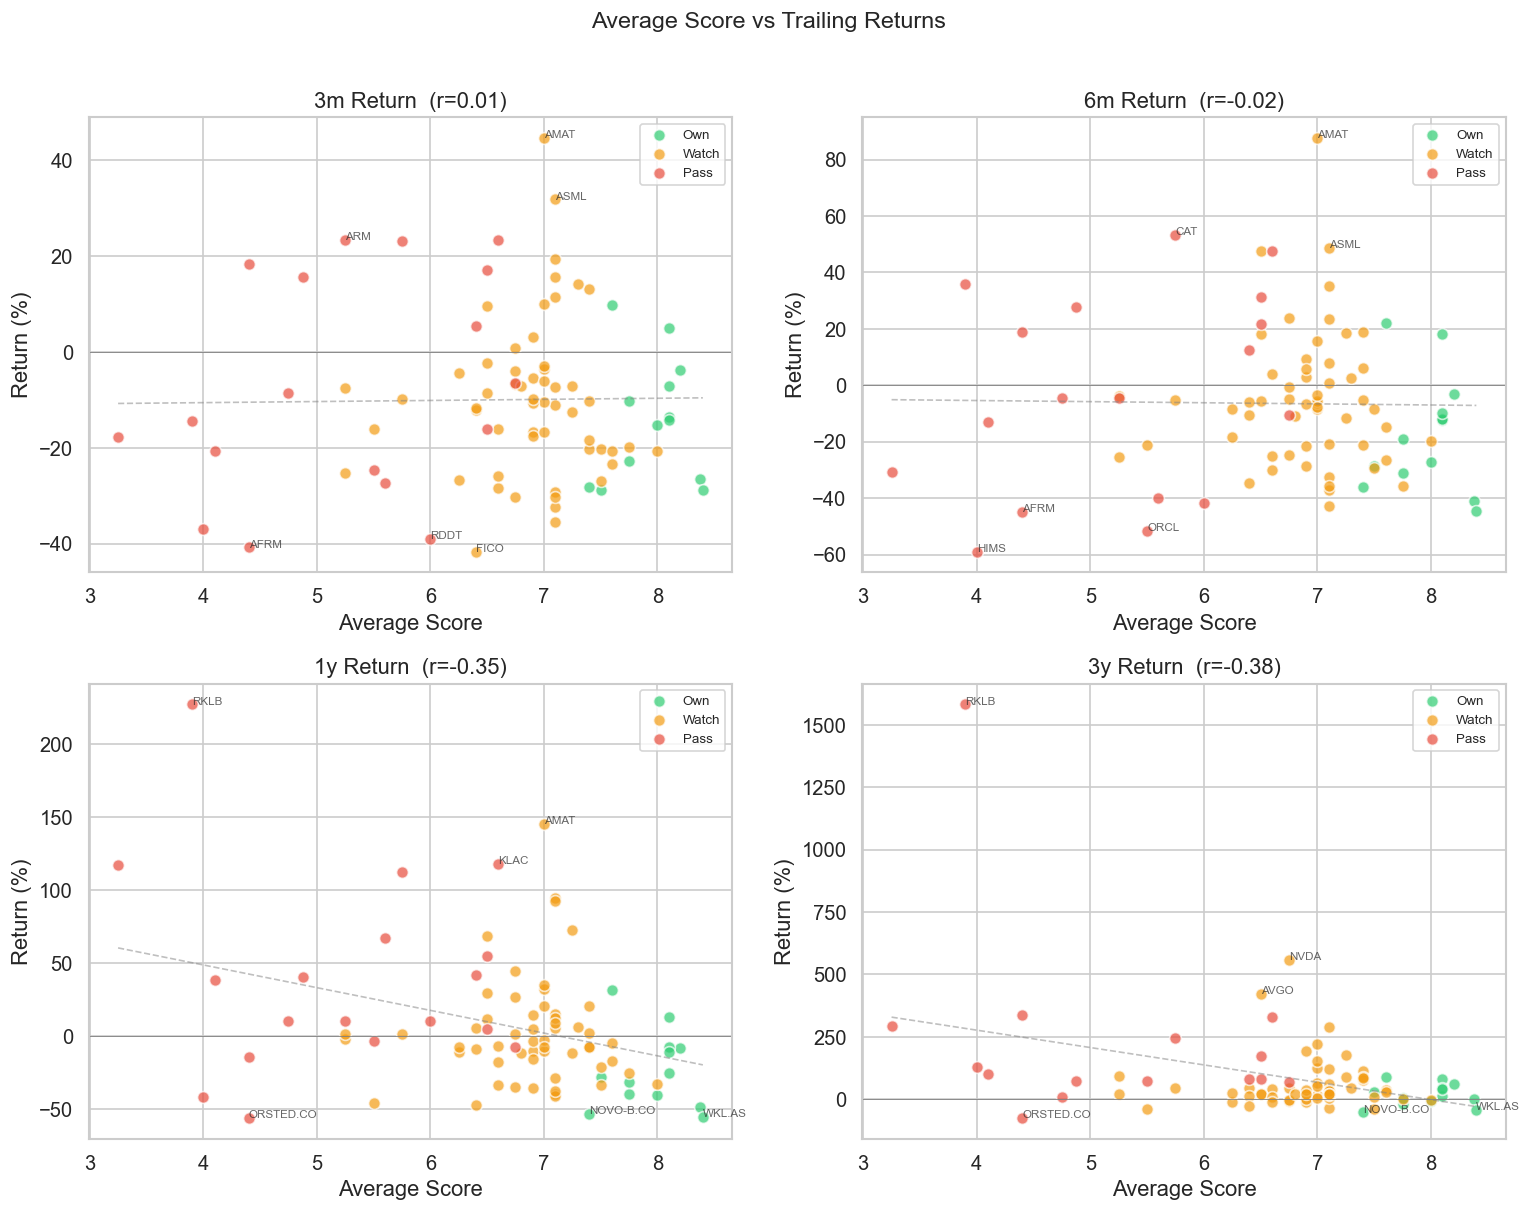

In [7]:
horizons = ['3m', '6m', '1y', '3y']
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, h in zip(axes.flat, horizons):
    col = f'return_{h}_pct'
    sub = df[['ticker', 'verdict', 'average_score', col]].dropna()
    for v in VERDICT_ORDER:
        mask = sub['verdict'] == v
        ax.scatter(sub.loc[mask, 'average_score'], sub.loc[mask, col],
                   c=VERDICT_COLORS[v], label=v, alpha=0.7, edgecolors='white', s=50)
    
    # label outliers (top/bottom 3 by return)
    for _, row in sub.nlargest(3, col).iterrows():
        ax.annotate(row['ticker'], (row['average_score'], row[col]), fontsize=7, alpha=0.7)
    for _, row in sub.nsmallest(3, col).iterrows():
        ax.annotate(row['ticker'], (row['average_score'], row[col]), fontsize=7, alpha=0.7)
    
    # trend line
    z = np.polyfit(sub['average_score'], sub[col], 1)
    x_line = np.linspace(sub['average_score'].min(), sub['average_score'].max(), 50)
    ax.plot(x_line, np.polyval(z, x_line), '--', color='grey', alpha=0.5, linewidth=1)
    
    r = sub['average_score'].corr(sub[col])
    ax.set_title(f'{h} Return  (r={r:.2f})')
    ax.set_xlabel('Average Score')
    ax.set_ylabel('Return (%)')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.legend(fontsize=8)

plt.suptitle('Average Score vs Trailing Returns', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Return Distributions by Verdict

/var/folders/dz/b_bcvwkd5ys8s55vn4mdkdnm0000gn/T/ipykernel_80944/683668171.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=VERDICT_ORDER, patch_artist=True, widths=0.6,
/var/folders/dz/b_bcvwkd5ys8s55vn4mdkdnm0000gn/T/ipykernel_80944/683668171.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=VERDICT_ORDER, patch_artist=True, widths=0.6,
/var/folders/dz/b_bcvwkd5ys8s55vn4mdkdnm0000gn/T/ipykernel_80944/683668171.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=VERDICT_ORDER, patch_artist=True, widths=0.6,
/var

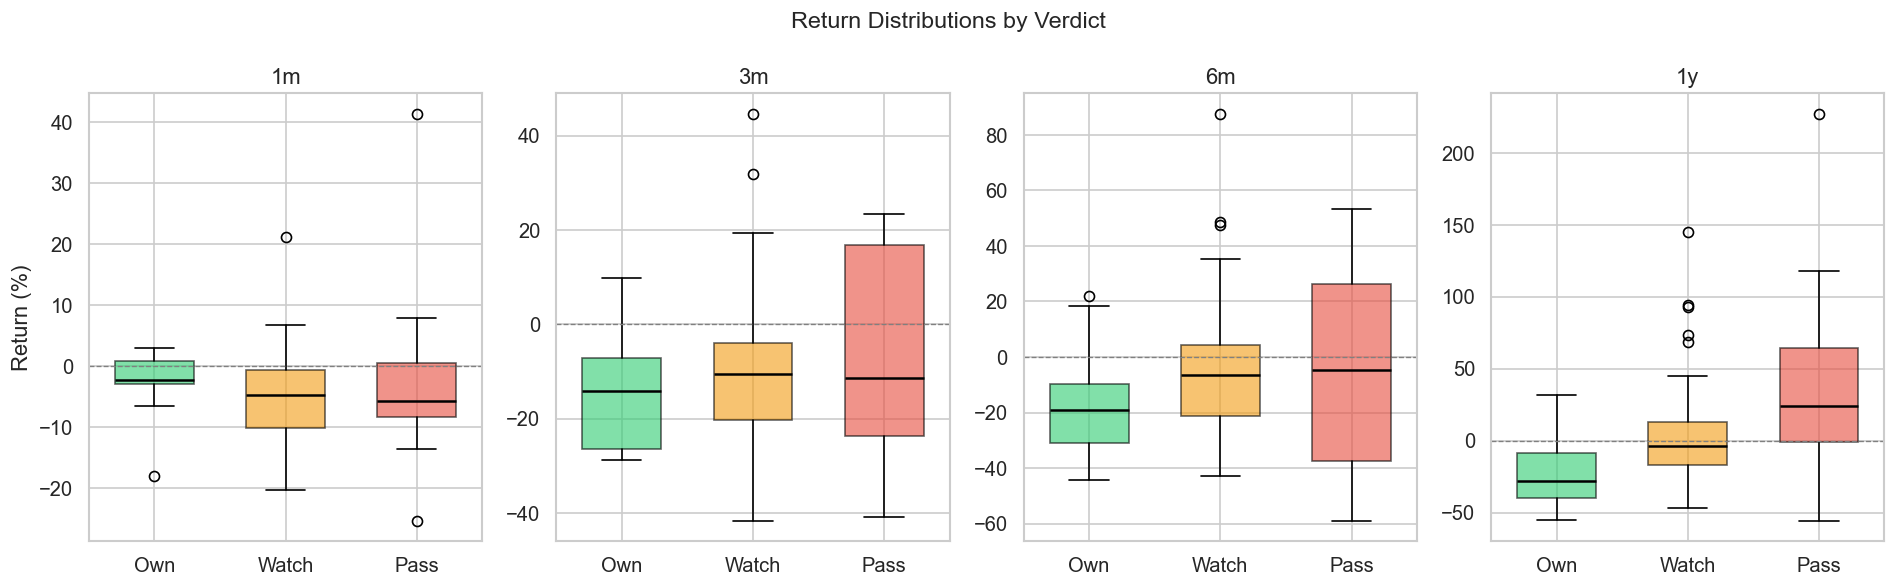

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)

for ax, h in zip(axes, ['1m', '3m', '6m', '1y']):
    col = f'return_{h}_pct'
    plot_data = [df.loc[df['verdict'] == v, col].dropna() for v in VERDICT_ORDER]
    bp = ax.boxplot(plot_data, labels=VERDICT_ORDER, patch_artist=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, v in zip(bp['boxes'], VERDICT_ORDER):
        patch.set_facecolor(VERDICT_COLORS[v])
        patch.set_alpha(0.6)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title(h)
    ax.set_ylabel('Return (%)' if h == '1m' else '')

plt.suptitle('Return Distributions by Verdict', fontsize=14)
plt.tight_layout()
plt.show()

## Biggest Mismatches

Stocks where score rank and return rank diverge most. High score + low return = potential value trap or too early. Low score + high return = market disagrees with our thesis.

In [9]:
# Use 6m as the primary mismatch horizon (long enough to be meaningful, short enough to be recent)
for h in ['6m', '1y']:
    col = f'return_{h}_pct'
    sub = df[['ticker', 'company', 'verdict', 'average_score', col]].dropna().copy()
    sub['score_pctile'] = sub['average_score'].rank(pct=True)
    sub['return_pctile'] = sub[col].rank(pct=True)
    sub['mismatch'] = sub['score_pctile'] - sub['return_pctile']
    
    print(f'\n{"=" * 60}')
    print(f'  {h.upper()} MISMATCHES')
    print(f'{"=" * 60}')
    
    print(f'\n  High score, low return (potential overrated):')
    top = sub.nlargest(5, 'mismatch')[['ticker', 'verdict', 'average_score', col]].copy()
    top[col] = top[col].map(lambda x: f'{x:+.1f}%')
    top['average_score'] = top['average_score'].map('{:.1f}'.format)
    top.columns = ['Ticker', 'Verdict', 'Score', f'{h} Return']
    display(top.reset_index(drop=True))
    
    print(f'\n  Low score, high return (market disagrees):')
    bot = sub.nsmallest(5, 'mismatch')[['ticker', 'verdict', 'average_score', col]].copy()
    bot[col] = bot[col].map(lambda x: f'{x:+.1f}%')
    bot['average_score'] = bot['average_score'].map('{:.1f}'.format)
    bot.columns = ['Ticker', 'Verdict', 'Score', f'{h} Return']
    display(bot.reset_index(drop=True))


  6M MISMATCHES

  High score, low return (potential overrated):


,Ticker,Verdict,Score,6m Return
0,WKL.AS,Own,8.4,-44.4%
1,CSU.TO,Own,8.4,-41.1%
2,VEEV,Watch,7.8,-35.7%
3,ROP,Own,7.8,-31.1%
4,CPRT,Own,8.0,-27.0%



  Low score, high return (market disagrees):


,Ticker,Verdict,Score,6m Return
0,RKLB,Pass,3.9,+35.8%
1,MAERSK-B.CO,Pass,4.9,+27.9%
2,CAT,Pass,5.8,+53.4%
3,ORSTED.CO,Pass,4.4,+18.9%
4,MRK,Watch,6.5,+47.6%



  1Y MISMATCHES

  High score, low return (potential overrated):


,Ticker,Verdict,Score,1y Return
0,WKL.AS,Own,8.4,-55.3%
1,CSU.TO,Own,8.4,-48.4%
2,CPRT,Own,8.0,-39.9%
3,ROP,Own,7.8,-39.4%
4,NOVO-B.CO,Own,7.4,-53.1%



  Low score, high return (market disagrees):


,Ticker,Verdict,Score,1y Return
0,RKLB,Pass,3.9,+227.2%
1,ALMU,Pass,3.2,+117.2%
2,TSLA,Pass,4.1,+38.3%
3,CAT,Pass,5.8,+112.7%
4,MAERSK-B.CO,Pass,4.9,+40.5%


## Key Findings

In [10]:
from IPython.display import Markdown, display

findings = []

# 1. Overall correlation direction
for h in RETURN_WINDOWS:
    col = f'return_{h}_pct'
    sub = df[['average_score', col]].dropna()
    if len(sub) >= 20:
        r = sub['average_score'].corr(sub[col])
        if abs(r) >= 0.20:
            d = 'positive' if r > 0 else 'negative'
            findings.append(f'**{h}**: Average score has a {d} correlation of **{r:.2f}** with returns (n={len(sub)})')

# 2. Verdict group spreads
for h in ['3m', '6m', '1y']:
    col = f'return_{h}_pct'
    for a, b in [('Own', 'Pass'), ('Own', 'Watch'), ('Watch', 'Pass')]:
        va = df.loc[df['verdict'] == a, col].dropna()
        vb = df.loc[df['verdict'] == b, col].dropna()
        if len(va) >= 5 and len(vb) >= 5:
            spread = va.median() - vb.median()
            if abs(spread) >= 8:
                better = a if spread > 0 else b
                findings.append(f'**{h}**: {a} vs {b} median spread = **{spread:+.1f}pp** ({better} outperforms)')

# 3. Which umbrella correlates most
best_corr, best_label, best_h = 0, '', ''
for si, sl in zip(UMBRELLA_ORDER, UMBRELLA_SHORT):
    for h in ['6m', '1y']:
        col = f'return_{h}_pct'
        sub = df[[si, col]].dropna()
        if len(sub) >= 20:
            r = sub[si].corr(sub[col])
            if abs(r) > abs(best_corr):
                best_corr, best_label, best_h = r, sl, h
if abs(best_corr) >= 0.15:
    findings.append(f'**Strongest umbrella signal**: {best_label} vs {best_h} return (r={best_corr:+.2f})')

if not findings:
    findings.append('No strong signal found between scores and returns at current thresholds.')

md = '\n'.join(f'- {f}' for f in findings)
display(Markdown(md))

- **1y**: Average score has a negative correlation of **-0.35** with returns (n=87)
- **3y**: Average score has a negative correlation of **-0.38** with returns (n=84)
- **6m**: Own vs Pass median spread = **-14.5pp** (Pass outperforms)
- **6m**: Own vs Watch median spread = **-12.5pp** (Watch outperforms)
- **1y**: Own vs Pass median spread = **-52.0pp** (Pass outperforms)
- **1y**: Own vs Watch median spread = **-23.9pp** (Watch outperforms)
- **1y**: Watch vs Pass median spread = **-28.2pp** (Pass outperforms)
- **Strongest umbrella signal**: MOS vs 1y return (r=-0.51)